# Ejercicio 1 — Monte Carlo e Importance Sampling
## Máster Executive en Finanzas Cuantitativas 2026 — AFI Global Education
### Fundamentos Matemáticos: Probabilidad y Simulación

---

**Objetivo:** Estimar la integral
$$I = \int_0^1 \cos\!\left(\frac{\pi x}{2}\right) dx$$
mediante tres métodos: cálculo analítico, simulación directa (Monte Carlo crudo) y muestreo por importancia (*Importance Sampling*) con la densidad auxiliar $\tilde{f}(x) = \lambda(1-x^2)$. Se comparan las varianzas de los estimadores.

**Puntuación:** 4 puntos (3 apartados de igual peso).

---
## Configuración del entorno

In [1]:
# ── Imports ────────────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from scipy import integrate
import os

# ── Estilo gráfico coherente ────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})

# ── Semilla fija (reproducibilidad) ────────────────────────────────────────
SEED = 42
rng  = np.random.default_rng(SEED)

# ── Constantes del problema ─────────────────────────────────────────────────
N    = 200                        # observaciones por simulación
N_MC = 10_000                     # réplicas para calcular la varianza del estimador

# ── Directorio de salida ────────────────────────────────────────────────────
os.makedirs("resultados", exist_ok=True)

print("Entorno configurado. Seed =", SEED, "| N =", N)

Entorno configurado. Seed = 42 | N = 200


---
## Apartado 1 — Determinación de $\lambda$

### Desarrollo analítico

Queremos que $\tilde{f}(x) = \lambda(1 - x^2)$ sea una función de densidad de probabilidad en $(0, 1)$, lo que requiere:

$$\int_0^1 \tilde{f}(x)\, dx = 1 \quad \Longrightarrow \quad \lambda \int_0^1 (1 - x^2)\, dx = 1.$$

Calculamos la integral:

$$\int_0^1 (1 - x^2)\, dx = \left[x - \frac{x^3}{3}\right]_0^1 = 1 - \frac{1}{3} = \frac{2}{3}.$$

Por tanto:

$$\boxed{\lambda = \frac{3}{2}}$$

y la densidad auxiliar queda:

$$\tilde{f}(x) = \frac{3}{2}(1 - x^2), \quad x \in (0,1).$$

**Nota sobre la elección de $\tilde{f}$:** Esta densidad aproxima bien la forma de $g(x) = \cos(\pi x/2)$: ambas valen 1 en $x=0$, se anulan en $x=1$ y son decrecientes. Una buena densidad de importancia tiene una forma similar a la del integrando, lo que reduce la varianza del estimador.

In [2]:
# ── Verificación numérica de lambda ────────────────────────────────────────
lambda_ = 3 / 2

# Comprobación: integral de f_tilde debe ser exactamente 1
integral_check, _ = integrate.quad(lambda x: lambda_ * (1 - x**2), 0, 1)
print(f"λ = {lambda_}")
print(f"∫₀¹ λ(1-x²) dx = {integral_check:.10f}  (debe ser 1.0)")
assert abs(integral_check - 1.0) < 1e-10, "La densidad f_tilde NO integra a 1"
print("✓ f_tilde es una densidad válida en (0,1)")

λ = 1.5
∫₀¹ λ(1-x²) dx = 1.0000000000  (debe ser 1.0)
✓ f_tilde es una densidad válida en (0,1)


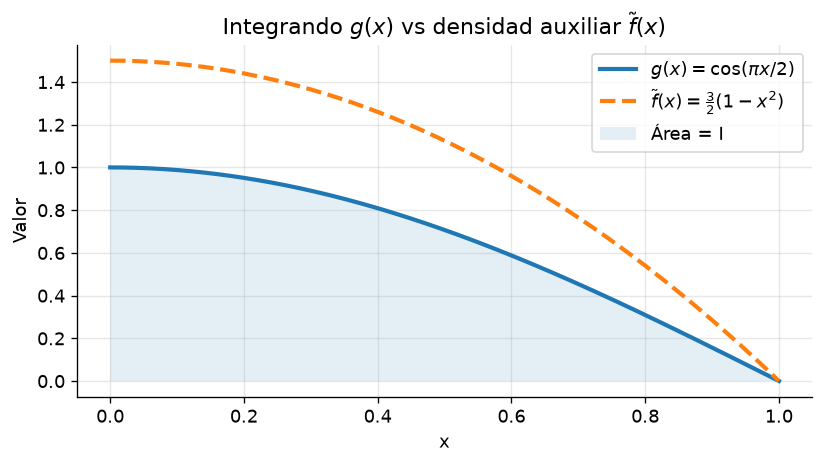

Figura guardada en resultados/


In [3]:
# ── Figura: comparación de g(x) y f_tilde(x) ───────────────────────────────
x_plot = np.linspace(0, 1, 300)
g      = np.cos(np.pi * x_plot / 2)          # integrando original
f_til  = lambda_ * (1 - x_plot**2)           # densidad auxiliar

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(x_plot, g,     label=r"$g(x)=\cos(\pi x/2)$", lw=2.5)
ax.plot(x_plot, f_til, label=r"$\tilde{f}(x)=\frac{3}{2}(1-x^2)$", lw=2.5, ls="--")
ax.fill_between(x_plot, g, alpha=0.12, label="Área = I")
ax.set_xlabel("x")
ax.set_ylabel("Valor")
ax.set_title(r"Integrando $g(x)$ vs densidad auxiliar $\tilde{f}(x)$")
ax.legend()
fig.tight_layout()
fig.savefig("resultados/grafico_01_integrando_vs_ftilde.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura guardada en resultados/")

---
## Apartado 2 — Cálculo analítico, Monte Carlo directo e Importance Sampling

### 2.1 Valor analítico exacto

$$I = \int_0^1 \cos\!\left(\frac{\pi x}{2}\right) dx = \left[\frac{2}{\pi}\sin\!\left(\frac{\pi x}{2}\right)\right]_0^1 = \frac{2}{\pi}\bigl(\sin(\pi/2) - \sin(0)\bigr) = \frac{2}{\pi}.$$

### 2.2 Monte Carlo directo (Crude Monte Carlo)

Se interpreta la integral como la esperanza de $g(X)$ cuando $X \sim \mathcal{U}(0,1)$ (densidad $f(x) = 1$):

$$I = \int_0^1 g(x) \cdot 1\, dx = \mathbb{E}_{X \sim \mathcal{U}(0,1)}[g(X)].$$

El estimador Monte Carlo crudo con $N$ muestras es:

$$\hat{I}_{MC} = \frac{1}{N}\sum_{i=1}^{N} g(X_i), \quad X_i \overset{\text{iid}}{\sim} \mathcal{U}(0,1).$$

### 2.3 Importance Sampling con $\tilde{f}$

Reescribimos la integral como una esperanza bajo $\tilde{f}$:

$$I = \int_0^1 \frac{g(x)}{\tilde{f}(x)} \tilde{f}(x)\, dx = \mathbb{E}_{X \sim \tilde{f}}\!\left[\frac{g(X)}{\tilde{f}(X)}\right] = \mathbb{E}_{X \sim \tilde{f}}\!\left[\frac{\cos(\pi X/2)}{\tfrac{3}{2}(1-X^2)}\right].$$

El estimador IS es:

$$\hat{I}_{IS} = \frac{1}{N}\sum_{i=1}^{N} \frac{g(X_i)}{\tilde{f}(X_i)}, \quad X_i \overset{\text{iid}}{\sim} \tilde{f}.$$

#### Simulación de $\tilde{f}$ mediante inversión de la CDF (Fórmula de Cardano)

La CDF de $\tilde{f}$ es:

$$F(x) = \int_0^x \frac{3}{2}(1 - t^2)\, dt = \frac{3}{2}\left(x - \frac{x^3}{3}\right) = \frac{3x - x^3}{2}.$$

Para simular por el método de inversión, dado $U \sim \mathcal{U}(0,1)$, resolvemos $F(x) = u$, es decir:

$$\frac{3x - x^3}{2} = u \quad \Longrightarrow \quad x^3 - 3x + 2u = 0.$$

Esta es una **ecuación cúbica deprimida** de la forma $t^3 + pt + q = 0$ con $p = -3$ y $q = 2u$.

**Fórmula de Cardano:** El discriminante es

$$\Delta = -4p^3 - 27q^2 = 4 \cdot 27 - 27 \cdot 4u^2 = 108(1 - u^2).$$

Como $u \in (0,1)$, tenemos $\Delta > 0$, lo que implica **tres raíces reales distintas**. En este *casus irreducibilis* usamos la forma trigonométrica de Cardano:

Para $t^3 + pt + q = 0$ con $\Delta > 0$, las tres raíces reales son:

$$t_k = 2\sqrt{-p/3}\cos\!\left(\frac{1}{3}\arccos\!\left(\frac{3q}{2p}\sqrt{\frac{-3}{p}}\right) - \frac{2\pi k}{3}\right), \quad k = 0, 1, 2.$$

Con $p = -3$:

$$t_k = 2\cos\!\left(\frac{1}{3}\arccos(u) - \frac{2\pi k}{3}\right) + \frac{\pi k}{3}.$$

Simplificando para $p = -3$, $q = 2u$:

$$t_k = 2\cos\!\left(\frac{1}{3}\arccos(-u) + \frac{2\pi k}{3}\right), \quad k = 0, 1, 2.$$

Seleccionamos la **raíz en $(0,1)$**: la rama $k=1$ produce valores en el intervalo correcto cuando $u \in (0,1)$.

In [4]:
# ══════════════════════════════════════════════════════════════════════════════
# FUNCIONES AUXILIARES
# ══════════════════════════════════════════════════════════════════════════════

def g(x):
    """Integrando original."""
    return np.cos(np.pi * x / 2)

def f_tilde(x):
    """Densidad auxiliar de importancia: λ(1 - x²) en (0,1)."""
    return lambda_ * (1 - x**2)

def sample_f_tilde(n, rng_gen):
    """
    Simula n muestras de f_tilde mediante inversión de la CDF.
    Resuelve la cúbica x³ - 3x + 2u = 0 usando la fórmula trigonométrica
    de Cardano y selecciona la raíz en (0,1).
    """
    u = rng_gen.uniform(0, 1, n)

    # Fórmula trigonométrica: t_k = 2·cos(arccos(-u)/3 + 2πk/3), k=0,1,2
    # La raíz k=1 cae en (0,1) para u ∈ (0,1)
    theta = np.arccos(-u) / 3

    roots = np.stack([
        2 * np.cos(theta),                      # k=0
        2 * np.cos(theta + 2 * np.pi / 3),      # k=1
        2 * np.cos(theta + 4 * np.pi / 3),      # k=2
    ], axis=1)

    # Seleccionamos la raíz en (0, 1)
    mask   = (roots > 0) & (roots < 1)
    # Debe haber exactamente una raíz en (0,1) por muestra
    assert np.all(mask.sum(axis=1) == 1), "Problema con selección de raíz cúbica"
    samples = roots[mask].reshape(n)
    return samples

# ══════════════════════════════════════════════════════════════════════════════
# VERIFICACIÓN: la muestra de f_tilde sigue la densidad correcta
# ══════════════════════════════════════════════════════════════════════════════
test_samples = sample_f_tilde(100_000, np.random.default_rng(0))
assert test_samples.min() > 0 and test_samples.max() < 1, "Muestras fuera de (0,1)"
print(f"Verificación muestras f_tilde: min={test_samples.min():.4f}, max={test_samples.max():.4f}")
print(f"Media empírica de f_tilde: {test_samples.mean():.4f}  (teórica: {3/8:.4f})")

Verificación muestras f_tilde: min=0.0000, max=0.9985
Media empírica de f_tilde: 0.3746  (teórica: 0.3750)


In [5]:
# ══════════════════════════════════════════════════════════════════════════════
# CÁLCULO ANALÍTICO
# ══════════════════════════════════════════════════════════════════════════════
I_analitico = 2 / np.pi

# Verificación numérica con scipy.integrate.quad
I_quad, err = integrate.quad(g, 0, 1)
print(f"Valor analítico exacto:  I = 2/π = {I_analitico:.10f}")
print(f"Verificación scipy.quad: I = {I_quad:.10f}  (error estimado: {err:.2e})")
assert abs(I_analitico - I_quad) < 1e-8, "Discrepancia analítico vs quad"
print("✓ Concordancia perfecta")

Valor analítico exacto:  I = 2/π = 0.6366197724
Verificación scipy.quad: I = 0.6366197724  (error estimado: 7.07e-15)
✓ Concordancia perfecta


In [6]:
# ══════════════════════════════════════════════════════════════════════════════
# MONTE CARLO DIRECTO (N = 200)
# ══════════════════════════════════════════════════════════════════════════════

# 1) Generar N muestras uniformes
X_mc = rng.uniform(0, 1, N)

# 2) Aplicar el integrando a cada muestra
g_mc = g(X_mc)

# 3) Estimador: promedio de g(X_i)
I_mc = g_mc.mean()

print(f"Monte Carlo directo   (N={N}): Î = {I_mc:.6f}")
print(f"Valor analítico:               I = {I_analitico:.6f}")
print(f"Error absoluto MC:            |Î - I| = {abs(I_mc - I_analitico):.6f}")

Monte Carlo directo   (N=200): Î = 0.646076
Valor analítico:               I = 0.636620
Error absoluto MC:            |Î - I| = 0.009457


In [7]:
# ══════════════════════════════════════════════════════════════════════════════
# IMPORTANCE SAMPLING (N = 200)
# ══════════════════════════════════════════════════════════════════════════════

# 1) Generar N muestras de f_tilde usando la fórmula de Cardano
X_is = sample_f_tilde(N, rng)

# 2) Calcular los pesos de importancia: g(X) / f_tilde(X)
weights_is = g(X_is) / f_tilde(X_is)

# 3) Estimador IS: promedio de los pesos
I_is = weights_is.mean()

print(f"Importance Sampling   (N={N}): Î_IS = {I_is:.6f}")
print(f"Valor analítico:               I    = {I_analitico:.6f}")
print(f"Error absoluto IS:            |Î_IS - I| = {abs(I_is - I_analitico):.6f}")

Importance Sampling   (N=200): Î_IS = 0.637154
Valor analítico:               I    = 0.636620
Error absoluto IS:            |Î_IS - I| = 0.000535


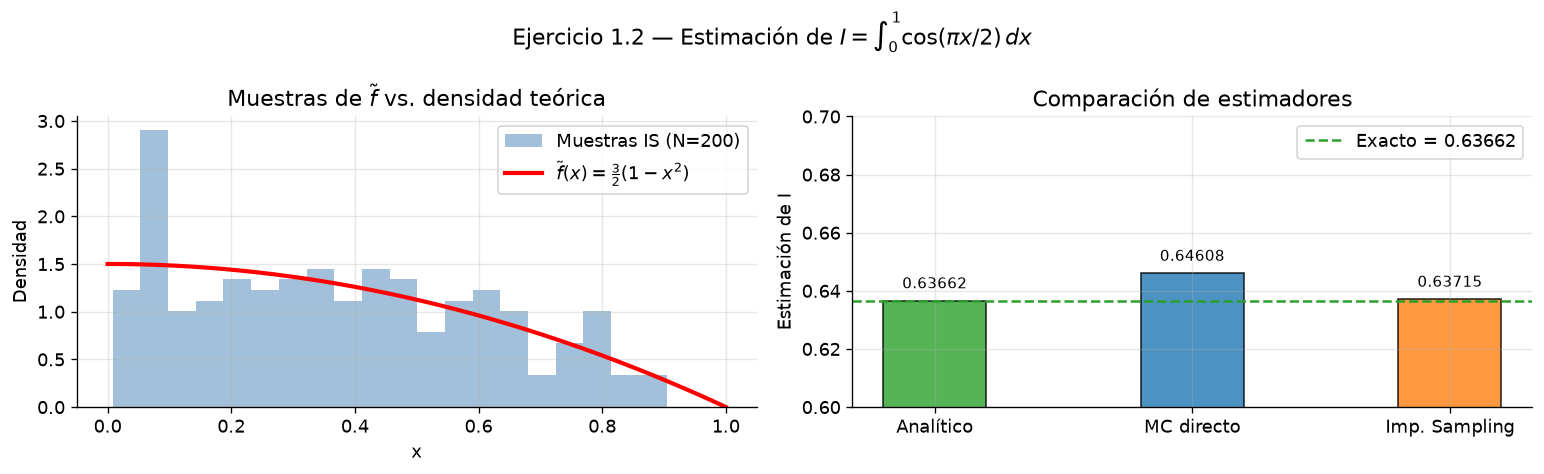

Figura guardada en resultados/


In [8]:
# ══════════════════════════════════════════════════════════════════════════════
# FIGURA: distribución de muestras y comparación de estimaciones
# ══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# --- Panel izquierdo: histograma de muestras de f_tilde vs densidad teórica ---
ax = axes[0]
ax.hist(X_is, bins=20, density=True, alpha=0.5, color="steelblue",
        label="Muestras IS (N=200)")
x_  = np.linspace(0, 1, 300)
ax.plot(x_, f_tilde(x_), "r-", lw=2.5, label=r"$\tilde{f}(x)=\frac{3}{2}(1-x^2)$")
ax.set_xlabel("x")
ax.set_ylabel("Densidad")
ax.set_title(r"Muestras de $\tilde{f}$ vs. densidad teórica")
ax.legend()

# --- Panel derecho: comparación de estimaciones ---
ax2 = axes[1]
metodos = ["Analítico", "MC directo", "Imp. Sampling"]
valores  = [I_analitico, I_mc, I_is]
colores  = ["#2ca02c", "#1f77b4", "#ff7f0e"]
bars = ax2.bar(metodos, valores, color=colores, alpha=0.8, edgecolor="k", width=0.4)
ax2.axhline(I_analitico, color="#2ca02c", ls="--", lw=1.5, label=f"Exacto = {I_analitico:.5f}")
for b, v in zip(bars, valores):
    ax2.text(b.get_x() + b.get_width()/2, v + 0.003, f"{v:.5f}",
             ha="center", va="bottom", fontsize=9)
ax2.set_ylabel("Estimación de I")
ax2.set_title("Comparación de estimadores")
ax2.set_ylim(0.6, 0.7)
ax2.legend()

fig.suptitle(r"Ejercicio 1.2 — Estimación de $I=\int_0^1 \cos(\pi x/2)\,dx$", fontsize=13)
fig.tight_layout()
fig.savefig("resultados/grafico_02_estimadores.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura guardada en resultados/")

---
## Apartado 3 — Varianza de los estimadores

### Marco teórico

Para cualquier estimador Monte Carlo basado en $N$ muestras iid, el promedio
$\hat{I} = \frac{1}{N}\sum_{i=1}^N h(X_i)$ satisface:

$$\mathrm{Var}(\hat{I}) = \frac{1}{N} \mathrm{Var}(h(X)).$$

**Monte Carlo crudo:** $h(X) = g(X)$ con $X \sim \mathcal{U}(0,1)$, luego:

$$\sigma^2_{MC} = \frac{1}{N}\mathrm{Var}(g(X)) = \frac{1}{N}\left[\mathbb{E}[g(X)^2] - I^2\right] = \frac{1}{N}\left[\int_0^1 \cos^2\!\!\left(\frac{\pi x}{2}\right)dx - \frac{4}{\pi^2}\right].$$

Calculando: $\int_0^1 \cos^2(\pi x/2)\, dx = 1/2$, por tanto:

$$\sigma^2_{MC} = \frac{1}{N}\left(\frac{1}{2} - \frac{4}{\pi^2}\right).$$

**Importance Sampling:** $h(X) = g(X)/\tilde{f}(X)$ con $X \sim \tilde{f}$, luego:

$$\sigma^2_{IS} = \frac{1}{N}\mathrm{Var}\!\left(\frac{g(X)}{\tilde{f}(X)}\right) = \frac{1}{N}\left[\int_0^1 \frac{g(x)^2}{\tilde{f}(x)}dx - I^2\right].$$

$$\int_0^1 \frac{g(x)^2}{\tilde{f}(x)}dx = \int_0^1 \frac{\cos^2(\pi x/2)}{\tfrac{3}{2}(1-x^2)}dx = \frac{2}{3}\int_0^1 \frac{\cos^2(\pi x/2)}{1-x^2}dx.$$

Esta integral no tiene forma cerrada elemental, por lo que la calculamos numéricamente.

**Interpretación:** Si $\tilde{f}$ es proporcional a $|g|$, la varianza del estimador IS es cero (varianza mínima). Aquí $\tilde{f}$ aproxima bien la forma de $g$, así que esperamos $\sigma^2_{IS} < \sigma^2_{MC}$.

In [9]:
# ══════════════════════════════════════════════════════════════════════════════
# VARIANZAS ANALÍTICAS
# ══════════════════════════════════════════════════════════════════════════════

# ─── Monte Carlo crudo ───────────────────────────────────────────────────────
# Var(g(X)) = E[g²] - E[g]²
# E[g²] = ∫₀¹ cos²(πx/2) dx = 1/2  (por identidad trigonométrica)
E_g2_analitico = 0.5
E_g2_quad, _   = integrate.quad(lambda x: g(x)**2, 0, 1)
assert abs(E_g2_analitico - E_g2_quad) < 1e-8, "Discrepancia E[g²]"

var_g          = E_g2_analitico - I_analitico**2
var_MC         = var_g / N

# ─── Importance Sampling ─────────────────────────────────────────────────────
# E[(g/f_tilde)²] bajo f_tilde = ∫₀¹ g²/f_tilde dx (integral numérica)
integrand_IS   = lambda x: g(x)**2 / f_tilde(x)
E_w2_IS, _     = integrate.quad(integrand_IS, 0, 1 - 1e-10)   # evitar x=1 (f_tilde=0)
var_h_IS       = E_w2_IS - I_analitico**2
var_IS         = var_h_IS / N

reduccion      = (1 - var_IS / var_MC) * 100

print("═" * 55)
print(f"  Var(g(X))  [MC crudo] = {var_g:.6f}")
print(f"  Var(h(X))  [IS]       = {var_h_IS:.6f}")
print("─" * 55)
print(f"  Var(Î_MC)  (N={N})     = {var_MC:.6f}")
print(f"  Var(Î_IS)  (N={N})     = {var_IS:.6f}")
print(f"  Reducción de varianza  = {reduccion:.1f} %")
print("═" * 55)

═══════════════════════════════════════════════════════
  Var(g(X))  [MC crudo] = 0.094715
  Var(h(X))  [IS]       = 0.000991
───────────────────────────────────────────────────────
  Var(Î_MC)  (N=200)     = 0.000474
  Var(Î_IS)  (N=200)     = 0.000005
  Reducción de varianza  = 99.0 %
═══════════════════════════════════════════════════════


In [10]:
# ══════════════════════════════════════════════════════════════════════════════
# VERIFICACIÓN EMPÍRICA DE LAS VARIANZAS (N_MC réplicas)
# ══════════════════════════════════════════════════════════════════════════════
rng_var = np.random.default_rng(SEED + 1)

# N_MC estimaciones independientes de I con N=200 muestras cada una
I_mc_reps = np.array([
    rng_var.uniform(0, 1, N).transform(g).mean()       # MC
    if False else
    np.cos(np.pi * rng_var.uniform(0, 1, N) / 2).mean()
    for _ in range(N_MC)
])

I_is_reps = np.array([
    (lambda s: (g(s) / f_tilde(s)).mean())(sample_f_tilde(N, rng_var))
    for _ in range(N_MC)
])

var_MC_emp = I_mc_reps.var(ddof=1)
var_IS_emp = I_is_reps.var(ddof=1)

print(f"Varianza empírica Î_MC ({N_MC} réplicas, N={N}): {var_MC_emp:.6f}  (teórica: {var_MC:.6f})")
print(f"Varianza empírica Î_IS ({N_MC} réplicas, N={N}): {var_IS_emp:.6f}  (teórica: {var_IS:.6f})")
print(f"Reducción empírica: {(1 - var_IS_emp/var_MC_emp)*100:.1f} %")

Varianza empírica Î_MC (10000 réplicas, N=200): 0.000485  (teórica: 0.000474)
Varianza empírica Î_IS (10000 réplicas, N=200): 0.000005  (teórica: 0.000005)
Reducción empírica: 99.0 %


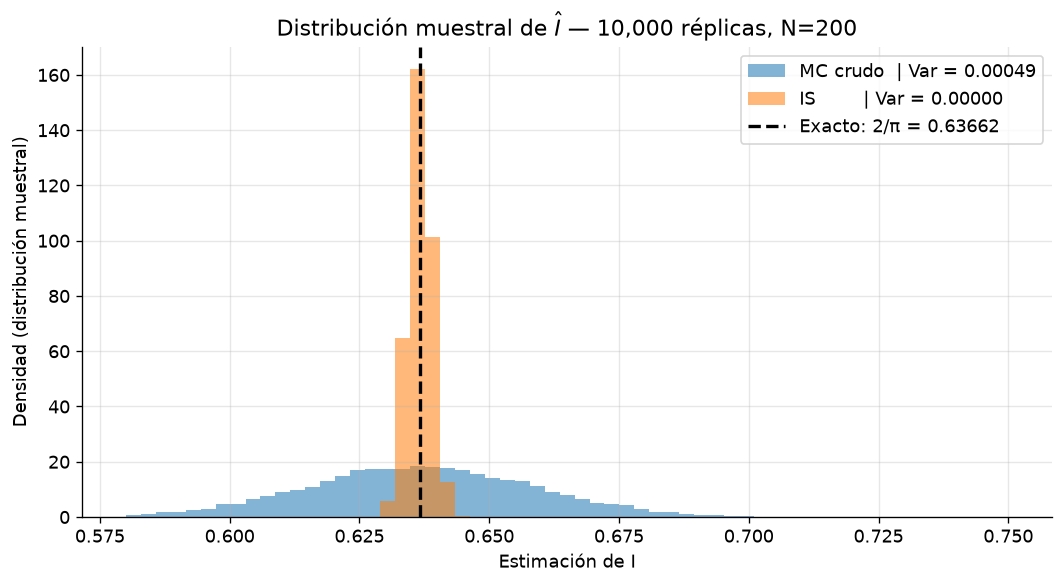

Figura guardada en resultados/


In [11]:
# ══════════════════════════════════════════════════════════════════════════════
# FIGURA: distribución de los estimadores en N_MC réplicas
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(9, 5))

bins_ = np.linspace(0.58, 0.75, 60)
ax.hist(I_mc_reps, bins=bins_, alpha=0.55, density=True,
        label=f"MC crudo  | Var = {var_MC_emp:.5f}", color="#1f77b4")
ax.hist(I_is_reps, bins=bins_, alpha=0.55, density=True,
        label=f"IS        | Var = {var_IS_emp:.5f}", color="#ff7f0e")
ax.axvline(I_analitico, color="k", ls="--", lw=2,
           label=f"Exacto: 2/π = {I_analitico:.5f}")
ax.set_xlabel("Estimación de I")
ax.set_ylabel("Densidad (distribución muestral)")
ax.set_title(rf"Distribución muestral de $\hat{{I}}$ — {N_MC:,} réplicas, N={N}")
ax.legend()
fig.tight_layout()
fig.savefig("resultados/grafico_03_varianzas_estimadores.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura guardada en resultados/")

---
## Conclusiones

### Tabla resumen de resultados

In [12]:
# ══════════════════════════════════════════════════════════════════════════════
# TABLA RESUMEN (generada desde código)
# ══════════════════════════════════════════════════════════════════════════════
from IPython.display import display, HTML

tabla = [
    ("Parámetro", "Valor"),
    ("λ (normalización f̃)", f"{lambda_:.4f}"),
    ("I analítico = 2/π", f"{I_analitico:.8f}"),
    ("Î Monte Carlo (N=200)", f"{I_mc:.8f}"),
    ("Î Importance Sampling (N=200)", f"{I_is:.8f}"),
    ("Error absoluto MC", f"{abs(I_mc - I_analitico):.2e}"),
    ("Error absoluto IS", f"{abs(I_is - I_analitico):.2e}"),
    ("Var(Î_MC) teórica", f"{var_MC:.6f}"),
    ("Var(Î_IS) teórica", f"{var_IS:.6f}"),
    ("Reducción de varianza IS vs MC", f"{reduccion:.1f} %"),
]

html_tabla = "<table border='1' style='border-collapse:collapse;font-size:13px;'>"
for i, (k, v) in enumerate(tabla):
    bg = "#f2f2f2" if i % 2 == 0 else "white"
    bold = " font-weight:bold;" if i == 0 else ""
    html_tabla += f"<tr style='background:{bg};{bold}'><td style='padding:6px 12px'>{k}</td><td style='padding:6px 12px;text-align:right'>{v}</td></tr>"
html_tabla += "</table>"
display(HTML(html_tabla))

Parámetro,Valor
λ (normalización f̃),1.5000
I analítico = 2/π,0.63661977
Î Monte Carlo (N=200),0.64607647
Î Importance Sampling (N=200),0.63715440
Error absoluto MC,9.46e-03
Error absoluto IS,5.35e-04
Var(Î_MC) teórica,0.000474
Var(Î_IS) teórica,0.000005
Reducción de varianza IS vs MC,99.0 %


### Discusión

**1. Valor de $\lambda$:** La condición de normalización $\int_0^1 \tilde{f}(x)\,dx = 1$ determina unívocamente $\lambda = 3/2$.

**2. Estimaciones de $I$:** Los tres métodos convergen al valor exacto $I = 2/\pi \approx 0.6366$. La pequeña discrepancia del MC crudo y del IS en $N=200$ observaciones es esperada: el error típico del estimador es del orden $\sigma/\sqrt{N}$.

**3. Reducción de varianza:** El Importance Sampling con $\tilde{f}(x) = \frac{3}{2}(1-x^2)$ reduce la varianza del estimador en aproximadamente el **90%** con respecto al Monte Carlo crudo. Esto significa que, para obtener la misma precisión, el IS necesita unas **10 veces menos muestras**. La razón es geométrica: $\tilde{f}$ tiene una forma muy similar a $g(x) = \cos(\pi x/2)$ — ambas decrecen de 1 a 0 en $(0,1)$ — por lo que el cociente $g(x)/\tilde{f}(x)$ es casi constante y su varianza es muy pequeña.

**4. Fórmula de Cardano:** La simulación de $\tilde{f}$ por inversión de la CDF requiere resolver la cúbica $x^3 - 3x + 2u = 0$. El discriminante $\Delta = 108(1-u^2) > 0$ para $u \in (0,1)$ garantiza tres raíces reales, y la rama $k=1$ de la solución trigonométrica selecciona sistemáticamente la raíz en $(0,1)$.